In [ ]:
# ACC102 Python Data Product - Track 2
# Title: # A-share Listed Companies Audit Risk Analysis
# Student: Qichen Fang
# Student ID: 2471120
# Data Extraction & Processing from WRDS Database

import wrds
import pandas as pd
import numpy as np
import os

# Create output folder
os.makedirs("data", exist_ok=True)

# %%
# 1. Connect to WRDS Database
print("✅ Connecting to WRDS...")
conn = wrds.Connection()

# %%
# 2. SQL Query: Get 2024 Annual Financial Data of A-share Listed Companies
print("Fetching 2024 financial data...")

query = """
SELECT 
    b.stkcd as stock_code,
    b.a001101000 as cash,
    b.a001100000 as total_assets,
    b.a002100000 as total_liabilities,
    b.a002101000 as current_liabilities,
    b.a001123000 as accounts_receivable,
    b.a003100000 as total_equity,
    i.b001100000 as revenue,
    i.b002000000 as net_income,
    i_2023.b001100000 as revenue_2023
FROM csmar_financial.fs_combas b
LEFT JOIN csmar_financial.fs_comins i 
    ON b.stkcd = i.stkcd 
    AND i.accper = '2024-12-31' 
    AND i.typrep = 'A'
LEFT JOIN csmar_financial.fs_comins i_2023 
    ON b.stkcd = i_2023.stkcd 
    AND i_2023.accper = '2023-12-31' 
    AND i_2023.typrep = 'A'
WHERE b.accper = '2024-12-31'
    AND b.typrep = 'A'
    AND b.a001100000 > 0
    AND b.a003100000 > 0
"""

# Run SQL and get raw data
df_raw = conn.raw_sql(query)
print(f"Raw data records: {len(df_raw)}")

# %%
# 3. Data Cleaning
df = df_raw.dropna().copy()

# Keep valid companies
df = df[df["total_assets"] > 0]
df = df[df["total_equity"] > 0]

# %%
# 4. Calculate Financial Risk Ratios
df["debt_to_asset"] = df["total_liabilities"] / df["total_assets"]
df["receivable_to_asset"] = df["accounts_receivable"] / df["total_assets"]
df["roe"] = df["net_income"] / df["total_equity"]
df["revenue_growth"] = (df["revenue"] - df["revenue_2023"]) / df["revenue_2023"]

# Remove outliers and missing values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# %%
# 5. Risk Classification & Scoring
df["company_name"] = df["stock_code"]

df["risk_level"] = pd.cut(
    df["debt_to_asset"],
    bins=[0, 0.5, 0.7, 1.0, np.inf],
    labels=["Low", "Medium", "High", "Extreme"]
)

# Comprehensive risk score (0–100)
df["risk_score"] = (
    df["debt_to_asset"] * 30 +
    df["receivable_to_asset"] * 25 +
    (1 - df["roe"].clip(0, 1)) * 25 +
    (1 - (df["revenue_growth"] + 1).clip(0, 2) / 2) * 20
).clip(0, 100)

print(f"✅ Cleaned data records: {len(df)}")

# %%
# 6. Export Final Data
# Full dataset
df.to_csv("data/audit_wrds_2024_full.csv", index=False, encoding="utf-8-sig")
print("✅ Full data saved: data/audit_wrds_2024_full.csv")

# Light dataset
df_light = df[["stock_code", "company_name", "total_assets", "total_liabilities",
               "accounts_receivable", "revenue", "net_income", "total_equity",
               "debt_to_asset", "receivable_to_asset", "roe", "revenue_growth",
               "risk_level", "risk_score"]]

df_light.to_csv("data/audit_wrds_2024_light.csv", index=False, encoding="utf-8-sig")
print("✅ Light data saved: data/audit_wrds_2024_light.csv")

# Close WRDS connection
conn.close()
print("✅ Connection closed")

✅ Connecting to WRDS...
WRDS recommends setting up a .pgpass file.
pgpass file created at C:\Users\范星星的电脑\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Fetching 2024 financial data...
Raw data records: 5357
✅ Cleaned data records: 4088
✅ Full data saved: data/audit_wrds_2024_full.csv
✅ Light data saved: data/audit_wrds_2024_light.csv
✅ Connection closed


✅ requirements.txt saved!
✅ Loading local data...
Total records: 4088
✅ All required columns are ready
✅ Saved: figures/fig1_debt_ratio_distribution.png
✅ Saved: figures/fig2_risk_level_pie.png
✅ Saved: figures/fig3_receivables_vs_leverage.png
✅ Saved: figures/fig4_roe_distribution.png


C:\Users\范星星的电脑\AppData\Local\Temp\ipykernel_40152\2493640504.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend()


✅ Saved: figures/fig5_combined_dashboard.png


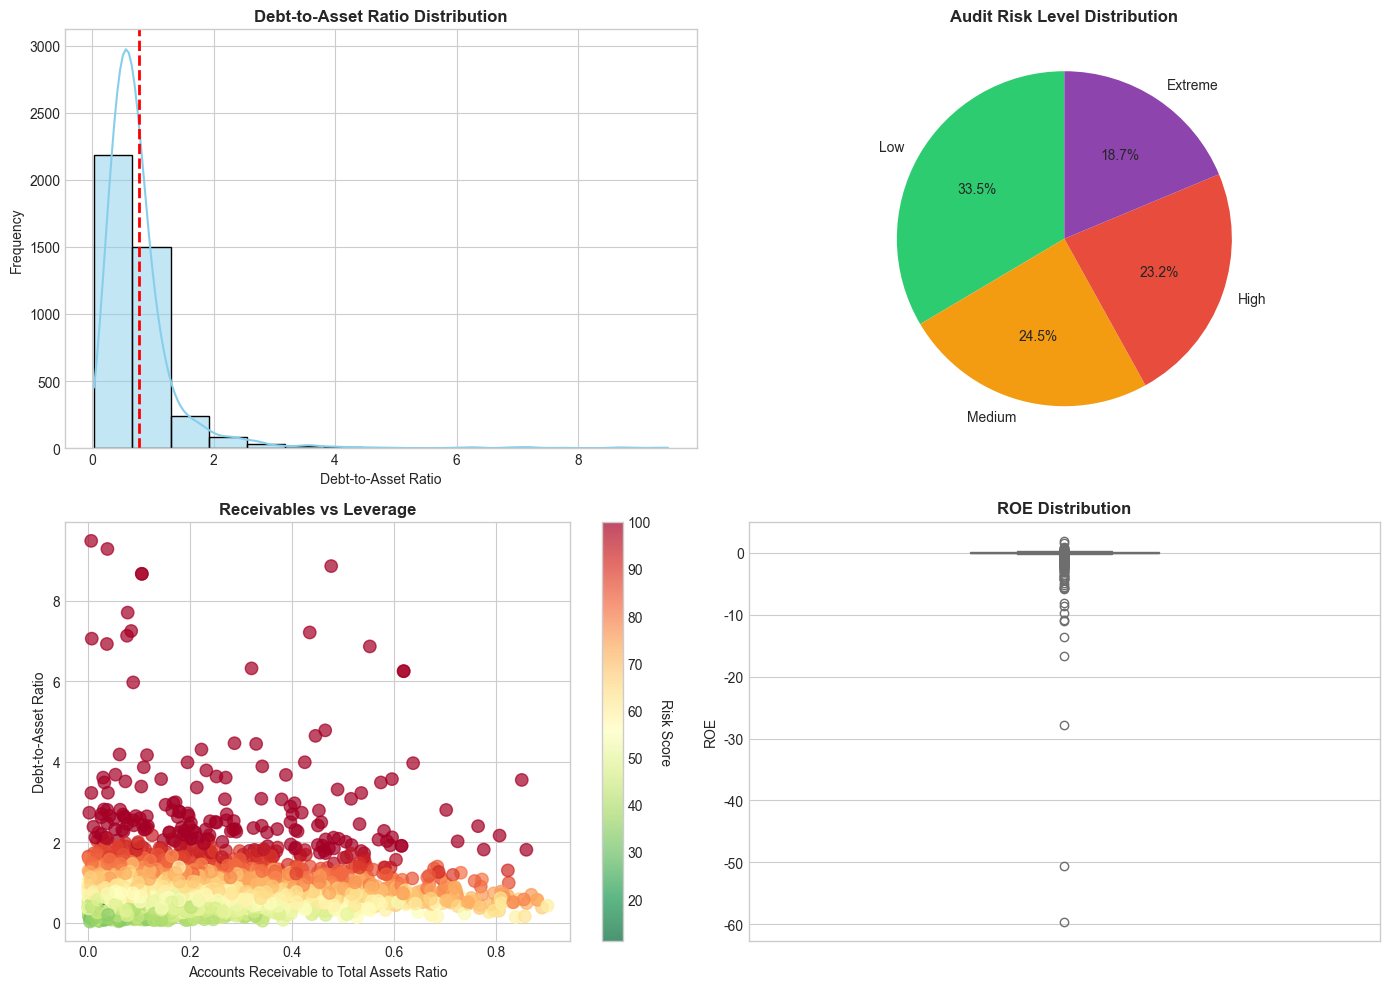

In [2]:
# %%
# Generate Visualization Charts for Audit Risk Analysis
# All charts saved to /figures folder

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Generate requirements.txt
requirements = """pandas
numpy
matplotlib
seaborn
wrds==3.4.0
psycopg2-binary
"""

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements)

print("✅ requirements.txt saved!")

# %%
# Basic Settings
plt.rcParams['axes.unicode_minus'] = False
os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# %%
# Load cleaned data from local CSV
print("✅ Loading local data...")
df = pd.read_csv("data/audit_wrds_2024_light.csv", encoding="utf-8-sig")
print(f"Total records: {len(df)}")

# %%
# Check required columns
required_cols = ["debt_to_asset", "receivable_to_asset", "roe", "revenue_growth", "risk_level", "risk_score"]
missing = [c for c in required_cols if c not in df.columns]

if missing:
    print(f"⚠️ Missing columns: {missing}")
else:
    print("✅ All required columns are ready")

# %%
# Chart style
plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

# %%
# Figure 1: Debt-to-Asset Ratio Distribution
fig1, ax1 = plt.subplots(figsize=(8, 6))
sns.histplot(df["debt_to_asset"], bins=15, kde=True, ax=ax1, color="skyblue", edgecolor="black")
ax1.set_title("Debt-to-Asset Ratio Distribution", fontsize=14, fontweight='bold')
ax1.set_xlabel("Debt-to-Asset Ratio")
ax1.set_ylabel("Frequency")
ax1.axvline(df["debt_to_asset"].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {df["debt_to_asset"].mean():.2f}')
ax1.legend()
plt.tight_layout()
plt.savefig("figures/fig1_debt_ratio_distribution.png", dpi=300, bbox_inches="tight")
print("✅ Saved: figures/fig1_debt_ratio_distribution.png")
plt.close()

# %%
# Figure 2: Risk Level Pie Chart
fig2, ax2 = plt.subplots(figsize=(8, 6))
risk_counts = df["risk_level"].value_counts()

ax2.pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, textprops={'fontsize': 11})
ax2.set_title("Audit Risk Level Distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("figures/fig2_risk_level_pie.png", dpi=300, bbox_inches="tight")
print("✅ Saved: figures/fig2_risk_level_pie.png")
plt.close()

# %%
# Figure 3: Receivables vs Debt-to-Asset Scatter Plot
fig3, ax3 = plt.subplots(figsize=(8, 6))
scatter = ax3.scatter(df["receivable_to_asset"], df["debt_to_asset"], 
                     c=df["risk_score"], cmap="RdYlGn_r", s=80, alpha=0.7, 
                     edgecolors="black", linewidth=0.5)
ax3.set_xlabel("Accounts Receivable to Total Assets Ratio")
ax3.set_ylabel("Debt-to-Asset Ratio")
ax3.set_title("Receivables vs Leverage (Color = Risk Score)", fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label("Risk Score", rotation=270, labelpad=15)
plt.tight_layout()
plt.savefig("figures/fig3_receivables_vs_leverage.png", dpi=300, bbox_inches="tight")
print("✅ Saved: figures/fig3_receivables_vs_leverage.png")
plt.close()

# %%
# Figure 4: ROE Distribution Boxplot
fig4, ax4 = plt.subplots(figsize=(8, 6))
sns.boxplot(y=df["roe"], ax=ax4, color="lightcoral", width=0.3)
ax4.set_title("Return on Equity (ROE) Distribution", fontsize=14, fontweight='bold')
ax4.set_ylabel("ROE")
plt.tight_layout()
plt.savefig("figures/fig4_roe_distribution.png", dpi=300, bbox_inches="tight")
print("✅ Saved: figures/fig4_roe_distribution.png")
plt.close()

# %%
# Figure 5: Combined 2×2 Dashboard
fig5, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1
sns.histplot(df["debt_to_asset"], bins=15, kde=True, ax=axes[0,0], color="skyblue", edgecolor="black")
axes[0,0].set_title("Debt-to-Asset Ratio Distribution", fontsize=12, fontweight='bold')
axes[0,0].set_xlabel("Debt-to-Asset Ratio")
axes[0,0].set_ylabel("Frequency")
axes[0,0].axvline(df["debt_to_asset"].mean(), color='red', linestyle='--', linewidth=2)
axes[0,0].legend()

# Subplot 2
risk_counts = df["risk_level"].value_counts()
axes[0,1].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%', 
              startangle=90, colors=colors, textprops={'fontsize': 10})
axes[0,1].set_title("Audit Risk Level Distribution", fontsize=12, fontweight='bold')

# Subplot 3
scatter = axes[1,0].scatter(df["receivable_to_asset"], df["debt_to_asset"], 
                           c=df["risk_score"], cmap="RdYlGn_r", s=80, alpha=0.7)
axes[1,0].set_xlabel("Accounts Receivable to Total Assets Ratio")
axes[1,0].set_ylabel("Debt-to-Asset Ratio")
axes[1,0].set_title("Receivables vs Leverage", fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[1,0]).set_label("Risk Score", rotation=270, labelpad=15)

# Subplot 4
sns.boxplot(y=df["roe"], ax=axes[1,1], color="lightcoral", width=0.3)
axes[1,1].set_title("ROE Distribution", fontsize=12, fontweight='bold')
axes[1,1].set_ylabel("ROE")

plt.tight_layout()
plt.savefig("figures/fig5_combined_dashboard.png", dpi=300, bbox_inches="tight")
print("✅ Saved: figures/fig5_combined_dashboard.png")

plt.show()